# "Watch the repo market" — does a funding spike warn of a crash? 🚨
### The September-2019 plumbing scare and the macro-Twitter oracle it spawned, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Repo_spike_%3D_flee%3F: Busted](https://img.shields.io/badge/Repo_spike_%3D_flee%3F-Busted-8b949e?style=flat-square)

In September 2019 the boring overnight "repo" rate — the cost of borrowing cash against Treasuries, the plumbing under the whole market — suddenly **spiked to ~10%**. The Fed had to rush in with emergency cash operations. Ever since, a piece of market lore has stuck: **when repo spikes, the plumbing is seizing, and risk assets are about to crack.** "Watch the repo market" became a permanent macro-Twitter refrain.

It *sounds* like a crystal ball. But there are only a handful of these spikes ever — and the one crash everyone "remembers" (March 2020) was actually a **buying** moment. This notebook shows why the oracle is vivid, confounded, and empty as a warning.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** There's no free, clean daily repo/SOFR-stress feed on yfinance, so we use a **hardcoded, sourced list of the famous repo-stress dates** and watch how stocks (SPY) and credit (HYG/LQD) actually moved after each. We call it an event list throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sofr_repo_stress import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
EVENTS = data.episode_dates()
print("real risk-asset cache present:", HAVE_REAL, "| repo-stress episodes:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-18', 'days': 4140, 'years': 16.5, 'n_events': 13, 'spy': {5: (5, 13, -0.71, 46, 0.29, 39, -0.96, 0.059), 20: (20, 13, 1.95, 46, 1.16, 31, 0.62, 0.755), 60: (60, 13, 5.21, 23, 3.41, 23, 0.66, 0.849)}, 'hyg': {5: (5, 13, -0.61, 54, 0.11, 40, -1.09, 0.024), 20: (20, 13, 1.06, 54, 0.43, 34, 0.91, 0.868), 60: (60, 13, 2.09, 15, 1.3, 25, 0.53, 0.811)}, 'lqd': {5: (5, 13, -0.51, 46, 0.08, 43, -1.65, 0.029), 20: (20, 13, 1.0, 46, 0.33, 39, 0.59, 0.886), 60: (60, 13, 2.61, 23, 0.99, 34, 1.0, 0.954)}, 'net': [(5, 13, 0.71, 0.66), (20, 13, -1.95, -2.0), (60, 13, -5.21, -5.26)], 'systemic': [(5, 3, -0.46, 0.29, -0.45, 0.247), (20, 3, 5.6, 1.16, 1.38, 0.98), (60, 3, 12.18, 3.41, 2.18, 0.992)], 'syn': [(0.0, 13, -0.93, 0.27, -0.88, 0.191), (-0.08, 13, -8.2, -0.24, -6.28, 0.0)], 'episodes': [('year-end-2018', 7.89), ('quarter-end-2019Q1', 2.87), ('sept-2019', -0.44), ('year-end-2019', -0.97), ('covid-mar-2020', 10.52), ('quarter-end-2020Q3', -2.09), ('year-end-2021', -5.18), ('quarter-end-2022Q3', 5.35), ('svb-mar-2023', 6.73), ('quarter-end-2023Q3', -2.74), ('quarter-end-2024Q3', 2.31), ('year-end-2024', 2.25), ('quarter-end-2025Q1', -1.15)]}


real risk-asset cache present: True | repo-stress episodes: 13


## The answer first

| Question | Answer |
|---|---|
| Right after a repo spike, do stocks dip? | **A little — for about a week.** SPY is down **0.7%** on average over 5 days vs **+0.3%** on a random day. So the scary story isn't *nothing*. |
| Is that dip reliable enough to act on? | **No.** It's well inside the noise (not statistically significant), and within a **month it flips**: SPY is **+1.9%** at 20 days, **+5.2%** at 60 — *better* than a normal stretch. |
| But March 2020 was a crash! | **That was COVID, not repo.** And SPY rose **+11%** over the month *after* the March-2020 funding seize — it was the **bottom**. The famous Sept-2019 spike? SPY ended roughly **flat**. |
| So why the prophetic reputation? | **A spike summons the backstop.** The Fed steps in *because* the plumbing seized, so the spike is usually followed by a **relief rally**. A dozen vivid episodes in an up-drifting market look ominous and then bounce. |

> The repo spike is a real, dramatic event. "Flee risk" is a confounded illusion. A dozen episodes — half of them not even bearish — can't be a warning system.

## 1 · The claim

> *"When overnight repo / SOFR spikes — the way it did in September 2019 — the funding plumbing of the financial system is seizing up. That's a flashing red light: get out of stocks and credit before the seizure spreads."*

The picture is intuitive and was seared in by a real event: on **17 September 2019** SOFR jumped to ~5.25% and overnight repo printed near **10%**, and the New York Fed restarted emergency repo operations for the first time since 2008. If the cost of the market's most basic funding can triple overnight, surely something is badly wrong. We'll line up every famous repo spike and ask what *actually* happened next.

## 2 · So what?

Two things hide inside "watch the repo market," and only one of them matters. (1) *Is a repo spike scary in the moment?* Sure — it's a genuine funding stress. The question that matters is (2) *does it forecast that **risk assets** fall by **more** than usual, reliably enough to bet on?* A vivid event that's followed by the market doing roughly its normal thing — or **rebounding**, because the Fed just rode in — is **not a warning**, it's a headline. And even a real warning is useless if it only fires **a dozen times in a decade and a half**: you can't run a fund on an oracle that rarely speaks and is half the time wrong.

## 3 · How would we even know?

We line up a **hardcoded, sourced list of 13 repo-stress episodes** — Sept 2019, the quarter/year-end funding turns, March 2020, SVB 2023, and the rest — over **16 years** (2010-01-04 → 2026-06-18). For each one:

1. **Wait one day** (no cheating — you couldn't trade the spike itself), then **buy or sell** the risk asset and hold **5 / 20 / 60 days**.
2. **Compare to normal.** How did SPY (stocks) and HYG/LQD (credit) do vs a *random* day over the same horizon (the base rate)?
3. **Stress the luck.** Draw the same handful of *random* dates thousands of times and ask how often pure chance looks just as scary. That's the honest test for a dozen-event signal.

## 4 · The teardown — let's actually look

**First, the episodes themselves.** Here's what SPY did over the *month after* each famous repo spike. If "flee risk" were right, these bars would mostly be deep red.

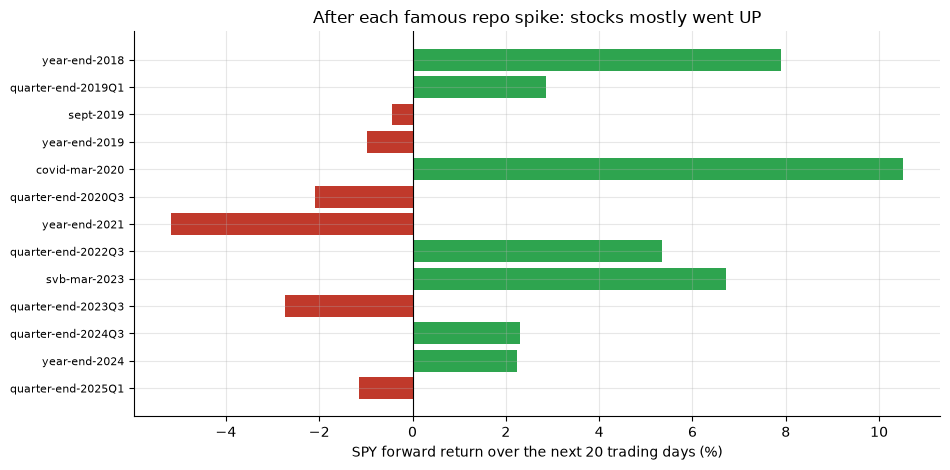

Sept-2019: -0.4% | COVID Mar-2020: +10.5% | SVB Mar-2023: +6.7%


In [2]:
tags = [t for t,_ in R['episodes']]; rets = [r for _,r in R['episodes']]
if HAVE_REAL:
    tab = data.episode_table(); tags=[]; rets=[]
    for d,row in tab.iterrows():
        rr = st.event_returns(F['SPY'], pd.DatetimeIndex([d]), 20)
        tags.append(row['tag']); rets.append(rr[0]*100 if len(rr) else np.nan)
cols = [RED if r<0 else GREEN for r in rets]
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.barh(range(len(tags)), rets, color=cols)
ax.set_yticks(range(len(tags))); ax.set_yticklabels(tags, fontsize=8)
ax.axvline(0, c='k', lw=.8); ax.invert_yaxis()
ax.set_xlabel('SPY forward return over the next 20 trading days (%)')
ax.set_title('After each famous repo spike: stocks mostly went UP')
plt.tight_layout(); plt.show()
print('Sept-2019:', f'{rets[2]:+.1f}%', '| COVID Mar-2020:', f'{rets[4]:+.1f}%', '| SVB Mar-2023:', f'{rets[8]:+.1f}%')

Look at the famous ones. **Sept 2019** — *the* episode — gave SPY ≈ **flat** (-0.4% over a month). **March 2020**, the crash everyone cites, was the **bottom**: SPY rose **+11%** over the next month. **SVB 2023**: **+7%**. The bars are a coin-toss of red and green, and the biggest greens are the scariest crises. That's the opposite of a warning.

**Now the averages.** For stocks and credit, the average move *right after* a spike (5 days) and a month later (20 days), next to a normal stretch (the base rate).

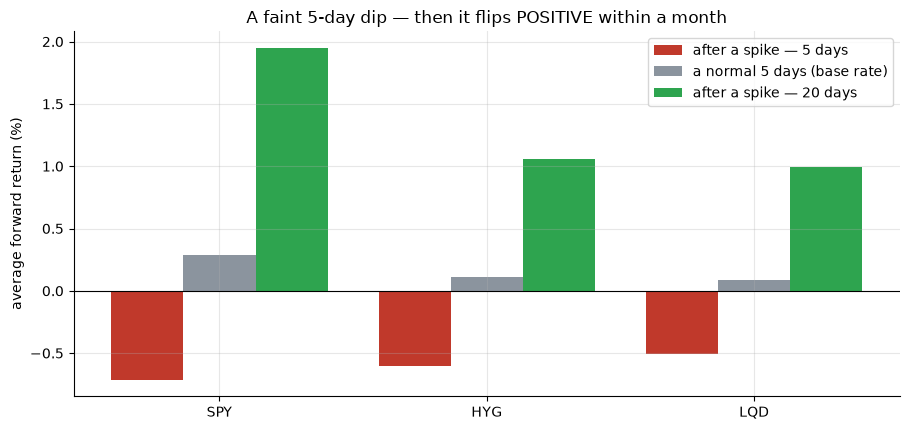

SPY: 5d after spike -0.71% vs normal +0.29% -> 20d: +1.95%


In [3]:
assets = ['SPY','HYG','LQD']
if HAVE_REAL:
    c5 = [st.summarize(F[a], EVENTS, 5)['cond_mean']*100 for a in assets]
    b5 = [st.summarize(F[a], EVENTS, 5)['base_mean']*100 for a in assets]
    c20 = [st.summarize(F[a], EVENTS, 20)['cond_mean']*100 for a in assets]
else:
    c5 = [R['spy'][5][2], R['hyg'][5][2], R['lqd'][5][2]]
    b5 = [R['spy'][5][4], R['hyg'][5][4], R['lqd'][5][4]]
    c20 = [R['spy'][20][2], R['hyg'][20][2], R['lqd'][20][2]]
x = np.arange(len(assets)); fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.27, c5, .27, color=RED, label='after a spike — 5 days')
ax.bar(x, b5, .27, color=GREY, label='a normal 5 days (base rate)')
ax.bar(x+.27, c20, .27, color=GREEN, label='after a spike — 20 days')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(assets)
ax.set_ylabel('average forward return (%)')
ax.set_title('A faint 5-day dip — then it flips POSITIVE within a month'); ax.legend()
plt.tight_layout(); plt.show()
print('SPY: 5d after spike', f'{c5[0]:+.2f}%', 'vs normal', f'{b5[0]:+.2f}%', '-> 20d:', f'{c20[0]:+.2f}%')

There's the whole story in one picture. At **5 days** there's a real but tiny dip — SPY **-0.7%** vs a normal **+0.3%**, credit a touch soft too. That's the kernel of truth the lore is built on. But by **20 days the red turns green**: every asset is *above* its base rate. The funding scare gets backstopped, and the market rebounds.

**Could a dozen random days look this scary?** The honest test: draw **13** *random* dates over and over and see whether the spike's 5-day average is unusually bad — or just ordinary bad luck.

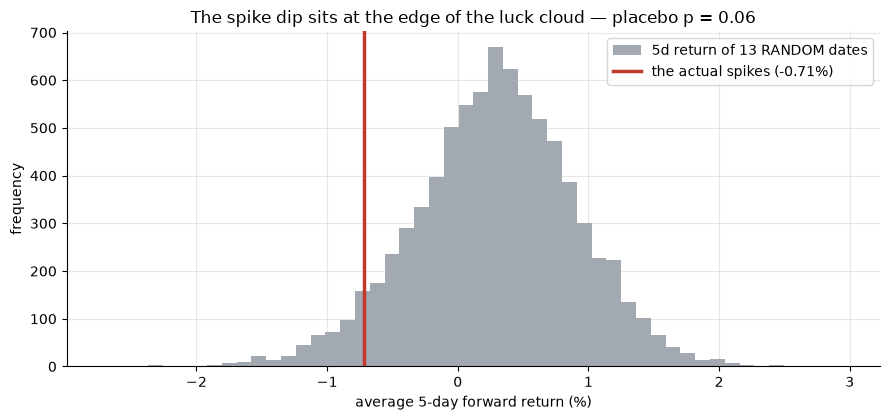

a random 13-date draw is at least this bearish 6% of the time — not rare enough


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F['SPY'], EVENTS, 5); obs = pl['event_mean']; pval = pl['p_value']
    p = F['SPY'].values; n=len(p); k=len(EVENTS); lag=1; h=5; vh=n-h-lag-1
    fwd = p[lag+h:lag+h+vh]/p[lag:lag+vh]-1; rng=np.random.default_rng(383)
    draws = np.array([fwd[rng.integers(0,vh,size=k)].mean() for _ in range(8000)])
else:
    obs = R['spy'][5][2]/100; pval = R['spy'][5][7]
    rng = np.random.default_rng(383); draws = rng.normal(R['spy'][5][4]/100, 0.011, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.8, label='5d return of 13 RANDOM dates')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'the actual spikes ({obs*100:+.2f}%)')
ax.set_xlabel('average 5-day forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The spike dip sits at the edge of the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random 13-date draw is at least this bearish {pval*100:.0f}% of the time — not rare enough')

The red line — the actual spikes — sits at the *edge* of the grey luck cloud, not out in the tail. About **6%** of random 13-date draws are at least as bearish. In plain terms: **the 5-day dip is roughly what you'd get from a dozen unlucky coin-flips** — and it's the only horizon that's even faintly bearish. Past a week it's gone.

## 5 · The verdict

- **Signal — None.** A faint, correctly-signed 5-day dip that **isn't statistically significant** and **flips positive within a month**. Real-as-a-flinch, empty-as-a-forecast.
- **Tradability — Mirage.** "Sell on the spike" sidesteps a noise-level **+0.7%** over 5 days, then **loses 2–5%** at 20/60 days — you sold into the rebound. And it fires **13 times in 16 years**.
- **"Repo spike = flee"? — Busted.** The one crash everyone cites (March 2020) is **COVID, not repo**, and it was a *bottom*. A handful of vivid, confounded episodes in a backstopped market is a **sample-size + confounding mirage**.

## 6 · Could you actually trade it? — the de-risk rule loses money

Forget significance for a second and just *run the rule*: every time repo spikes, sell SPY for H days, then buy back. How much loss did you "avoid"? (Positive = you dodged a drop; negative = you sold low and missed the bounce.)

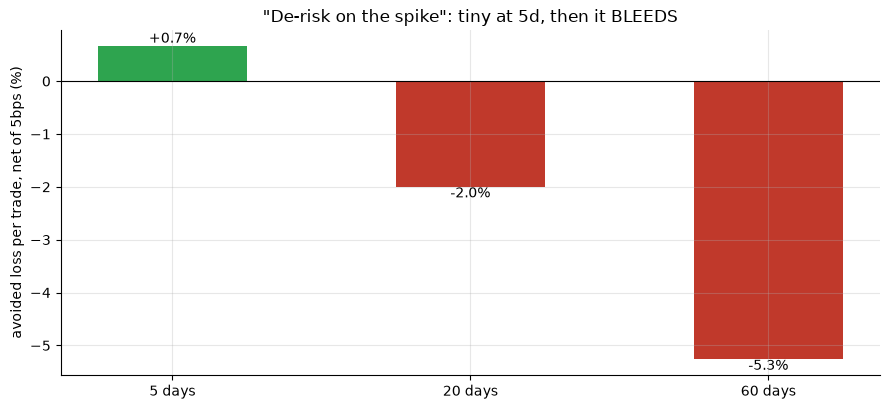

avoided loss net@5bps by horizon: {'5d': 0.66, '20d': -2.0, '60d': -5.26}


In [5]:
if HAVE_REAL:
    rows = [(h,)+ (lambda c:(c['gross_mean']*100, c['net_mean']*100))(st.net_of_costs(F['SPY'], EVENTS, h, 5.0)) for h in (5,20,60)]
else:
    rows = [(h,g,nn) for (h,_,g,nn) in R['net']]
hs = [r[0] for r in rows]; g=[r[1] for r in rows]; nv=[r[2] for r in rows]
x = np.arange(len(hs)); fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(x, nv, .5, color=[GREEN if v>=0 else RED for v in nv])
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h} days' for h in hs])
ax.set_ylabel('avoided loss per trade, net of 5bps (%)')
ax.set_title('"De-risk on the spike": tiny at 5d, then it BLEEDS')
for i,v in enumerate(nv): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print('avoided loss net@5bps by horizon:', {f'{h}d': round(v,2) for h,v in zip(hs,nv)})

At 5 days you "save" a noise-level **+0.7%**; by 20 days you've **lost 2.0%** and by 60 days **5.3%**, because you sold into the recovery the Fed engineered. Costs (5 bps) are irrelevant — the rule is **wrong-signed** past a week. You can't build a portfolio around an oracle that whispers a dozen times a decade and then loses money.

## 7 · Going further 🚪

- **The slow cousin.** [Study 115 — Credit-Spreads](../../115-credit-spreads/) asks whether the *credit cycle* (not the overnight plumbing) carries a forward warning — a fairer test of "stress predicts risk-off."
- **Another stress gauge.** [Study 111 — VIX-Term-Structure](../../111-vix-term-structure/): a different "flashing light" said to precede sell-offs; same base-rate question.
- **The backdrop.** [Study 317 — Fed-Balance-Sheet](../../317-fed-balance-sheet/) — reserves and QT, which is *why* repo gets tight at quarter-ends in the first place.

*Think a repo spike beats the market by more than luck? Get a real SOFR feed, define a mechanical threshold, draw the same number of random dates, and show the spikes landing **outside** the cloud on the bearish side — then we'll talk.*